In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import json
import glob

In [2]:
# ==========================================
# 1. EXTENDED PHYSICAL GRID
# ==========================================
grid_points = 1000 
# We extend the math calculation out to 8e-19 so the right side 
# of the bell curve has room to be calculated without being cut off.
#a0_max = 3e-19
a0_grid = np.linspace(-0.0003, 0.0003, grid_points) 

# Initialize array to hold the sum of the log-KDEs
sum_log_kdes = np.zeros_like(a0_grid)

# Locate JSON files
file_pattern = 'results/*/None_result.json'
result_files = glob.glob(file_pattern)
valid_events = 0

print(f"Found {len(result_files)} JSON files. Processing events...")

for file in result_files:  # Process only the first 10 files for testing
    
    with open(file, 'r') as f:
        data = json.load(f)
        a0_samples = np.array(data['posterior']['content']['A']) 
        mean_a0 = np.mean(a0_samples)
        std_a0 = np.std(a0_samples)

        if mean_a0 - std_a0 < 0 and mean_a0 + std_a0 > 0:
            kde = gaussian_kde(a0_samples)
            sum_log_kdes += kde.logpdf(a0_grid)
            valid_events += 1
            #plt.plot(a0_grid,kde.logpdf(a0_grid), label=f'Event {valid_events}', alpha=0.5)
        #plt.axvline(0, color='gray', linestyle='--')
        else:
            print(f"Skipped {file} due to unphysical A_0 distribution (mean ± std does not include 0). Mean: {mean_a0:.2e}, Std: {std_a0:.2e}")
    

print(f"Successfully processed {valid_events} events.")

Found 103 JSON files. Processing events...
Skipped results/81/None_result.json due to unphysical A_0 distribution (mean ± std does not include 0). Mean: 1.05e-04, Std: 4.96e-06
Skipped results/68/None_result.json due to unphysical A_0 distribution (mean ± std does not include 0). Mean: -1.00e-02, Std: 3.63e-07
Skipped results/54/None_result.json due to unphysical A_0 distribution (mean ± std does not include 0). Mean: 9.99e-03, Std: 3.92e-06
Successfully processed 100 events.


In [3]:
# ==========================================
# 2. COMBINED POSTERIOR (A_0^N CORRECTION)
# ==========================================
joint_log_pdf_A0 =  sum_log_kdes

# Convert safely out of log-space
pdf_A0_unnormalized = np.exp(joint_log_pdf_A0 - np.max(joint_log_pdf_A0))

# Normalize the total area to 1
pdf_A0_normalized = pdf_A0_unnormalized / np.trapezoid(pdf_A0_unnormalized, a0_grid)

#correction_pdf_normalized = a0_grid ** valid_events / np.trapezoid(a0_grid ** valid_events, a0_grid)

pdf_A0_final = pdf_A0_normalized #* correction_pdf_normalized

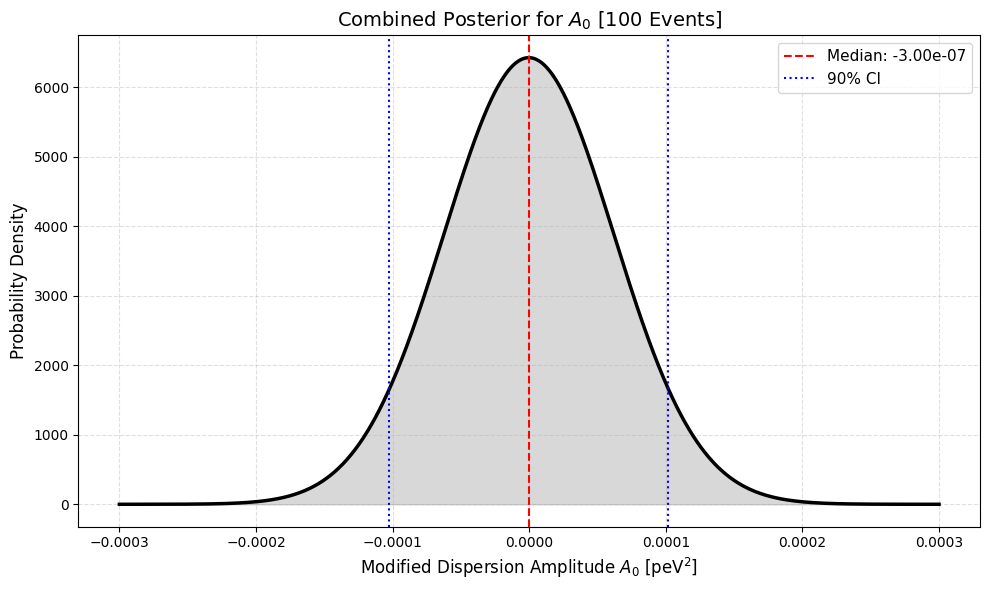

In [4]:
# ==========================================
# 3. PLOTTING WITH TARGETED ZOOM
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(a0_grid, pdf_A0_final, color='black', linewidth=2.5)
plt.fill_between(a0_grid, pdf_A0_final, alpha=0.3, color='gray')

# Calculate credible intervals
cdf_A0 = np.cumsum(pdf_A0_final) * (a0_grid[1] - a0_grid[0])
lower_bound = a0_grid[np.searchsorted(cdf_A0, 0.05, side='right')]
upper_bound = a0_grid[np.searchsorted(cdf_A0, 0.95, side='right')]
median = a0_grid[np.searchsorted(cdf_A0, 0.50, side='right')]

# Plot the markers
plt.axvline(median, color='red', linestyle='--', label=f'Median: {median:.2e}')
plt.axvline(lower_bound, color='blue', linestyle=':', label='90% CI')
plt.axvline(upper_bound, color='blue', linestyle=':')

plt.title(f'Combined Posterior for $A_0$ [{valid_events} Events]', fontsize=14)
plt.xlabel('Modified Dispersion Amplitude $A_0$ [peV$^2$]', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)

# ==========================================
# THE FIX: ZOOM IN ON THE BELL CURVE
# ==========================================
# This forces the graph window to only show the region between 3e-19 and 7e-19,
# perfectly framing the ascending slope, the peak at 5e-19, and the descending slope.
#plt.xlim(2e-19, 4e-19) 

plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()